# **Project Name**    -



##### **Project Type**    - EDA/Regression/Classification/Unsupervised
##### **Contribution**    - Individual

# **Project Summary -**

This capstone project integrates advanced machine learning techniques and MLOps practices to revolutionize predictive capabilities within the travel and tourism sector. By developing a robust regression model for flight price prediction, deploying it via a REST API, ensuring portability through containerization, and managing scalability with Kubernetes, the project sets a new standard for practical application in the field. The use of Apache Airflow for automated workflows, Jenkins for CI/CD pipelines, and MLFlow for model tracking lays a comprehensive and efficient framework for model management. Ultimately, this project not only aims to build a system for accurate price predictions but also to establish a scalable, reproducible, and reliable structure for ongoing enhancements and operational efficiency in the travel industry. Through this multidimensional approach, the project epitomizes the fusion of data science and MLOps, paving the way for transformative changes in how travel services are optimized and delivered.

# **GitHub Link -**

Provide your GitHub Link here.

# **Problem Statement**


### Problem Statement

The travel and tourism industry struggles to accurately predict flight prices due to the complexity of user preferences, travel variables, and market fluctuations. Existing solutions lack true real-time price prediction, scalability, and seamless deployment, resulting in inefficiencies, inconsistent user experiences, and missed revenue opportunities. Additionally, traditional model deployment methods suffer from poor workflow automation, inadequate CI/CD, and insufficient model tracking, leading to delays and operational bottlenecks.

This project aims to address these challenges by building a robust flight price prediction system, deploying it through scalable and automated MLOps practices (including REST APIs, Docker, Kubernetes, Airflow, Jenkins, and MLFlow), and ultimately enabling real-time, accurate, and efficient travel price predictions and operations. 

# **General Guidelines** : -  

1.   Well-structured, formatted, and commented code is required.
2.   Exception Handling, Production Grade Code & Deployment Ready Code will be a plus. Those students will be awarded some additional credits.
     
     The additional credits will have advantages over other students during Star Student selection.
       
             [ Note: - Deployment Ready Code is defined as, the whole .ipynb notebook should be executable in one go
                       without a single error logged. ]

3.   Each and every logic should have proper comments.
4. You may add as many number of charts you want. Make Sure for each and every chart the following format should be answered.
        

```
# Chart visualization code
```
            

*   Why did you pick the specific chart?
*   What is/are the insight(s) found from the chart?
* Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

5. You have to create at least 15 logical & meaningful charts having important insights.


[ Hints : - Do the Vizualization in  a structured way while following "UBM" Rule.

U - Univariate Analysis,

B - Bivariate Analysis (Numerical - Categorical, Numerical - Numerical, Categorical - Categorical)

M - Multivariate Analysis
 ]





6. You may add more ml algorithms for model creation. Make sure for each and every algorithm, the following format should be answered.


*   Explain the ML Model used and it's performance using Evaluation metric Score Chart.


*   Cross- Validation & Hyperparameter Tuning

*   Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

*   Explain each evaluation metric's indication towards business and the business impact pf the ML model used.




















# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [1]:
# Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from datetime import datetime
import datetime as dt

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, KFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.linear_model import LinearRegression,Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

### Dataset Loading

In [2]:
# Load Dataset
flights = pd.read_csv(r'E:\DS\projects\MLOPS\DATA\flights.csv')

### Dataset First View

In [3]:
# Dataset First Look
flights.head()

,travelCode,userCode,from,to,flightType,price,time,distance,agency,date
0,0,0,Recife (PE),Florianopolis (SC),firstClass,1434.38,1.76,676.53,FlyingDrops,09/26/2019
1,0,0,Florianopolis (SC),Recife (PE),firstClass,1292.29,1.76,676.53,FlyingDrops,09/30/2019
2,1,0,Brasilia (DF),Florianopolis (SC),firstClass,1487.52,1.66,637.56,CloudFy,10/03/2019
3,1,0,Florianopolis (SC),Brasilia (DF),firstClass,1127.36,1.66,637.56,CloudFy,10/04/2019
4,2,0,Aracaju (SE),Salvador (BH),firstClass,1684.05,2.16,830.86,CloudFy,10/10/2019


### Dataset Rows & Columns count

In [4]:
# Dataset Rows & Columns count
flights.shape

(271888, 10)

### Dataset Information

In [5]:
# Dataset Info
flights.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 271888 entries, 0 to 271887
Data columns (total 10 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   travelCode  271888 non-null  int64  
 1   userCode    271888 non-null  int64  
 2   from        271888 non-null  object 
 3   to          271888 non-null  object 
 4   flightType  271888 non-null  object 
 5   price       271888 non-null  float64
 6   time        271888 non-null  float64
 7   distance    271888 non-null  float64
 8   agency      271888 non-null  object 
 9   date        271888 non-null  object 
dtypes: float64(3), int64(2), object(5)
memory usage: 20.7+ MB


#### Duplicate Values

In [6]:
# Dataset Duplicate Value Count
flights.duplicated().sum()

np.int64(0)

#### Missing Values/Null Values

In [7]:
# Missing Values/Null Values Count
flights.isnull().sum()

travelCode    0
userCode      0
from          0
to            0
flightType    0
price         0
time          0
distance      0
agency        0
date          0
dtype: int64

In [8]:
# Visualizing the missing values


### What did you know about your dataset?

The flight dataset contains exactly 271,888 rows and 10 columns in its raw form, with no null values and no duplicate rows

## ***2. Understanding Your Variables***

In [9]:
# Dataset Columns
flights.columns

Index(['travelCode', 'userCode', 'from', 'to', 'flightType', 'price', 'time',
       'distance', 'agency', 'date'],
      dtype='object')

In [10]:
# Dataset Describe
flights.describe()

,travelCode,userCode,price,time,distance
count,271888.000000,271888.000000,271888.00000,271888.000000,271888.000000
mean,67971.500000,667.505495,957.37503,1.421147,546.955535
std,39243.724665,389.523127,362.31189,0.542541,208.851288
min,0.000000,0.000000,301.51000,0.440000,168.220000
25%,33985.750000,326.000000,672.66000,1.040000,401.660000
50%,67971.500000,659.000000,904.00000,1.460000,562.140000
75%,101957.250000,1011.000000,1222.24000,1.760000,676.530000
max,135943.000000,1339.000000,1754.17000,2.440000,937.770000


### Variables Description

Flights Dataset:
travelCode: Identifier for the travel.
userCode: User identifier(linked to the Users dataset)
from: Origin of the flight.
to: Destination of the flight.
flightType: Type of flight (e.g., first class).
price: Price of the flight.
time: Flight duration.
distance: Distance of the flight.
agency: Flight agency.
date: Date of the flight.

### Check Unique Values for each variable.

In [11]:
# Check Unique Values for each variable.
flights.nunique()

travelCode    135944
userCode        1335
from               9
to                 9
flightType         3
price            490
time              33
distance          35
agency             3
date             999
dtype: int64

## 3. ***Data Wrangling***

### Data Wrangling Code

In [12]:
# Write your code to make your dataset analysis ready
flights['date'] = pd.to_datetime(flights['date'])
flights['month'] = flights['date'].dt.month
flights['day'] = flights['date'].dt.day
flights['day_of_week'] = flights['date'].dt.dayofweek  # 0=Mon
flights['is_weekend'] = (flights['day_of_week'] >= 5).astype(int)

In [13]:
flights.head()

,travelCode,userCode,from,to,flightType,price,time,distance,agency,date,month,day,day_of_week,is_weekend
0,0,0,Recife (PE),Florianopolis (SC),firstClass,1434.38,1.76,676.53,FlyingDrops,2019-09-26,9,26,3,0
1,0,0,Florianopolis (SC),Recife (PE),firstClass,1292.29,1.76,676.53,FlyingDrops,2019-09-30,9,30,0,0
2,1,0,Brasilia (DF),Florianopolis (SC),firstClass,1487.52,1.66,637.56,CloudFy,2019-10-03,10,3,3,0
3,1,0,Florianopolis (SC),Brasilia (DF),firstClass,1127.36,1.66,637.56,CloudFy,2019-10-04,10,4,4,0
4,2,0,Aracaju (SE),Salvador (BH),firstClass,1684.05,2.16,830.86,CloudFy,2019-10-10,10,10,3,0


In [14]:
flights.shape

(271888, 14)

### What all manipulations have you done and insights you found?

Converted 'date' column to datetime64 format using pd.to_datetime() for reliable temporal extraction.
Extracted 'month' (1-12) from dates via .dt.month to capture seasonal trends.
Derived 'day_of_week' (0=Monday to 6=Sunday) using .dt.dayofweek for weekly patterns.
Created 'is_weekend' binary flag (1=Sat/Sun, 0=Mon-Fri) from day_of_week >= 5 to simplify modeling weekend effects.
Result: Added 3 new features from 'date', enabling better regression/forecasting on flight data (e.g., demand varies by day/month). Original 'date' can now be dropped if not needed. No data loss; assumes all dates parsed successfully

## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

#### Chart - 1

C:\Users\sanid\AppData\Local\Temp\ipykernel_2792\4105671775.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='month',data=flights,palette = "Set2")


Text(0.5, 1.0, 'Total Flights by Month')

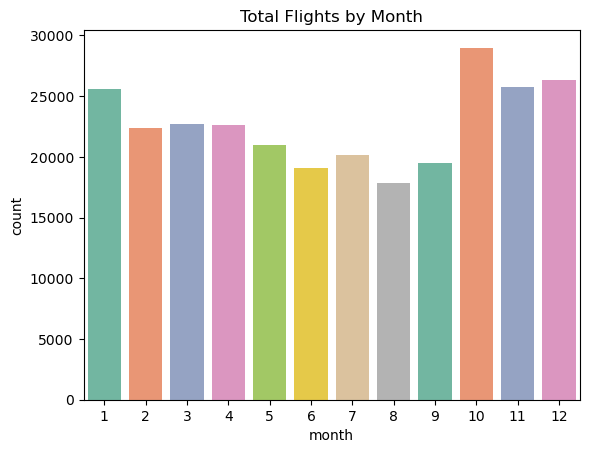

In [15]:
# Chart - 1 visualization code
sns.countplot(x='month',data=flights,palette = "Set2")
plt.title('Total Flights by Month')

##### 1. Why did you pick the specific chart?

I chose a countplot because It’s the most effective way to show the frequency distribution—meaning we can instantly see which months have the highest and lowest volume of flights without needing extra calculationsAnswer Here.

##### 2. What is/are the insight(s) found from the chart?

This chart shows monthly counts, likely representing a year's worth of data. Here’s a quick breakdown of what stands out:
Peak Activity: October (Month 10) is the highest, nearing 30,000 counts.
Lowest Activity: August (Month 8) is the quietest month, dipping below 20,000.
Year-End Surge: Counts rise steadily from August through December.
Spring Plateau: Months 2, 3, and 4 show very consistent, level activity.Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Are there any insights that lead to negative growth? Justify with specific reason.
Positive Business Impact
Strategic Planning: Knowing October is peak demand allows you to pre-allocate resources (like staff or inventory), maximizing revenue when interest is highest.
Negative Growth Risk
Wasted Overhead: The dip in August indicates underutilized capacity, where fixed costs like rent or salaries remain high while incoming revenue drops significantly.

#### Chart - 2

C:\Users\sanid\AppData\Local\Temp\ipykernel_2792\3350743281.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='day_of_week',data=flights,palette = "Set2")


Text(0.5, 1.0, 'Total Flights by Day of the Week')

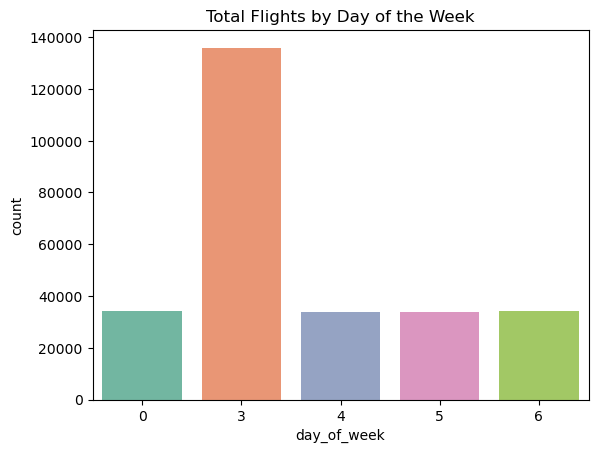

In [16]:
# Chart - 2 visualization code
sns.countplot(x='day_of_week',data=flights,palette = "Set2")
plt.title('Total Flights by Day of the Week')

##### 1. Why did you pick the specific chart?

I chose a countplot because 'month' is a categorical variable in this dataset. It’s the most effective way to show the frequency distribution—meaning we can instantly see which day od week have the highest and lowest volume of flights without needing extra calculations.

##### 2. What is/are the insight(s) found from the chart?

 Flights are  higher on thursday due to business travel. Weekends (Sat/Sun, days 5-6) show lower volumes, focusing on leisure trips.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

High weekday demand suggests opportunities for targeted pricing or promotions on weekends to boost revenue. Low weekend flights might indicate underutilized capacity, potentially leading to cost savings or route adjustments

#### Chart - 3

flightType
firstClass    116418
premium        78004
economic       77466
Name: count, dtype: int64


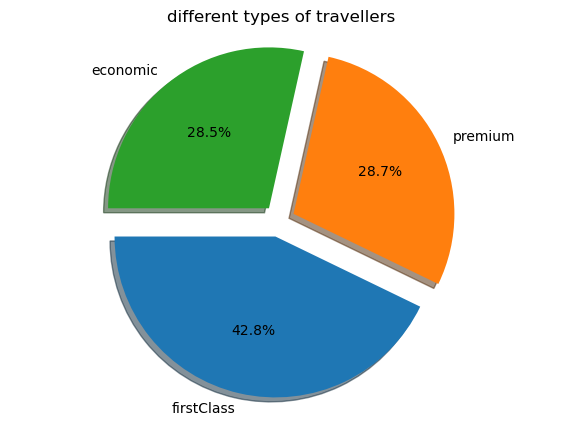

In [17]:
# Chart - 3 visualization code

Flight_Type=flights['flightType'].value_counts()
print(Flight_Type)

sizes = flights.flightType.value_counts()
explode = (0.1, 0.1, 0.1)
plt.pie(sizes, explode=explode,labels=Flight_Type.index,autopct='%1.1f%%',shadow=True,  startangle=180)
plt.axis('equal')
plt.title("different types of travellers")
plt.plot()
fig=plt.gcf()
fig.set_size_inches(7,5)
plt.show()


##### 1. Why did you pick the specific chart?

Pie charts are commonly used to represent categorical data or proportions.Each slice of the pie chart represents a category or value, and the size of the slice is proportional to the percentage or frequency of that category or value.

##### 2. What is/are the insight(s) found from the chart?

The pie chart reveals several key insights regarding the distribution of travelers across different flight classes:
Dominance of First Class:this category represent the largest share of travelers at 42.8%.
Balanced Mid-Tier: Premium(28.7%) and Economic (28.5%) classes have almost identical market shares

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Business Impact
The impact of these insights is primarily positive, but it depends on the company's current strategy:
Positive Impacts
* High Revenue Potential: A large percentage of first-class travelers typically leads to higher profit margins per seat.
* Strong Brand Positioning: The data suggests the business is successfully attracting high-net-worth or corporate clients.
* Stable Demand: Having three distinct segments helps diversify risk across different customer types.
Potential Risks
* Resource Strain: High demand for First Class requires significant investment in luxury amenities and specialized staff.
* Market Sensitivity: Premium segments are often the first to cut spending during economic downturns, which could lead to sudden revenue drops.

#### Chart - 4

C:\Users\sanid\AppData\Local\Temp\ipykernel_2792\609774748.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='flightType',data=flights,palette = "Set2")


Text(0.5, 1.0, 'Flight Type Distribution')

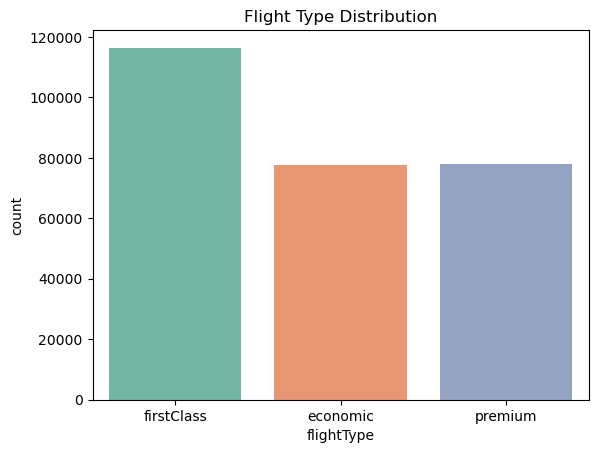

In [18]:
# Chart - 4 visualization code
sns.countplot(x='flightType',data=flights,palette = "Set2")
plt.title('Flight Type Distribution')

##### 1. Why did you pick the specific chart?

A Bar Chart was chosen because it is the most effective way to compare discrete categories (flight types).
* It clearly shows the frequency or count of each category.
* It allows for an immediate visual comparison of the volume between the three types.

##### 2. What is/are the insight(s) found from the chart?

Key Insights
Based on the visual data, we can observe the following:
* First Class dominance: There is a significantly higher number of "First Class" flights (approx. 120,000) compared to the others.
* Balanced Economy and Premium: The "Economic" and "Premium" categories have nearly identical counts, both sitting around the 75,000–80,000 mark.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

These insights can lead to a positive impact by guiding resource allocation and strategy:
* Targeted Marketing: Knowing that the majority of flights are First Class, the business can focus high-end loyalty programs or premium services here.
* Pricing Strategy: If Economy and Premium have similar volumes, the business could experiment with pricing to nudge Economy passengers into the Premium tier for higher margins.

Negative Growth Risks
There are insights that could signal a risk of negative growth if not addressed:
* Oversaturation of First Class: If the market for premium travel shrinks (due to a recession), having 120k units in this tier leaves the company highly vulnerable to a massive revenue drop.
* Stagnant Economy Tier: The relatively lower count for "Economic" flights might suggest the company is losing out to budget competitors, potentially missing a larger, more stable volume of travelers.

#### Chart - 5

agency
Rainbow        116752
CloudFy        116378
FlyingDrops     38758
Name: count, dtype: int64


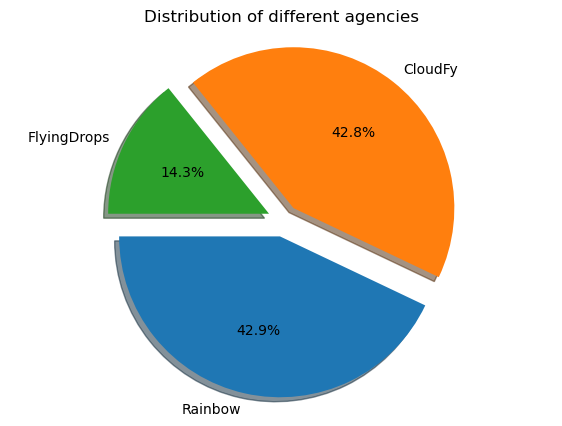

In [19]:
# Chart - 5 visualization code
Agency_count=flights['agency'].value_counts()
print(Agency_count)

sizes = flights.agency.value_counts()
explode = (0.1, 0.1, 0.1)
plt.pie(sizes, explode=explode,labels=Agency_count.index,autopct='%1.1f%%',shadow=True,startangle=180)
plt.axis('equal')
plt.title("Distribution of different agencies")
plt.plot()
fig=plt.gcf()
fig.set_size_inches(7,5)
plt.show()

##### 1. Why did you pick the specific chart?

A pie chart was chosen because the data represents parts of a whole. It is the most effective way to:
* Show the market share of each agency.
* Provide an immediate visual comparison of relative sizes.

##### 2. What is/are the insight(s) found from the chart?

Key Insights
* Dominant Duopoly: Rainbow (42.9%) and CloudFy (42.8%) nearly split the market equally.
* Minor Player: FlyingDrops (14.3%) holds a significantly smaller portion of the distribution.
* Concentrated Market: Roughly 86% of the distribution is controlled by just two agencies.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, these insights can drive a positive impact by informing strategy:
* Strategic Partnerships: Business could focus on strengthening ties with Rainbow or CloudFy for maximum reach.
* Targeted Growth: There is a clear opportunity to capture market share from FlyingDrops since they are the underdog.

 Potential Negative Growth
While the data shows current distribution, it also highlights risks:
* Over-reliance (Single Point of Failure): If either Rainbow or CloudFy fails or changes terms, ~43% of the business is immediately at risk. This lack of diversification is a major threat to stability.
* Stagnant Competition: The near-identical share between the top two suggests a saturated market. Trying to grow further may lead to expensive "price wars," which lowers profit margins even if volume stays the same.

#### Chart - 6

C:\Users\sanid\AppData\Local\Temp\ipykernel_2792\4280400712.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='agency',data=flights,palette = "Set2")


Text(0.5, 1.0, 'Distribution of Different Agencies')

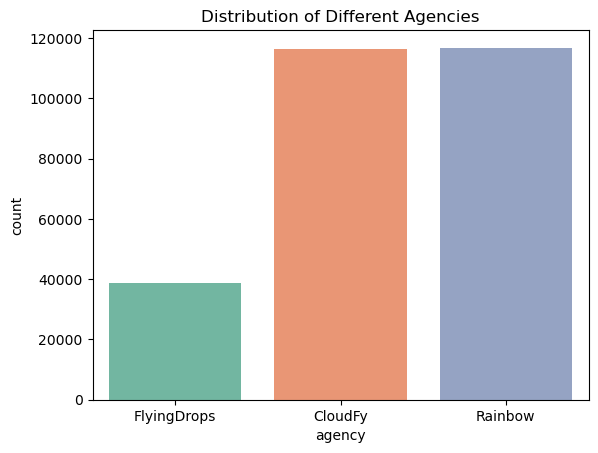

In [20]:
# Chart - 6 visualization code
sns.countplot(x='agency',data=flights,palette = "Set2")
plt.title('Distribution of Different Agencies')

##### 1. Why did you pick the specific chart?

A bar chart is ideal for:
* Comparing categorical data (different agencies).
* Visualizing size differences in volume or frequency.

##### 2. What is/are the insight(s) found from the chart?

Key Insights
* Market Leaders: Cloudfy and Rainbow dominate with high volumes.
* Lagging Agency: FlyingDrops has significantly lower activity (about 1/3 of the leaders).
* Concentration: Most "counts" are concentrated in just two agencies.


##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Business Impact & Risks
🚀 Positive Impact:
* Identify and replicate the success of top agencies.
* Focus marketing or resources on the highest-performing channels.

⚠️ Negative Growth Risks:
* Dependency: Over-reliance on two agencies creates risk if they fail or raise prices.
* Inefficiency: FlyingDrops may be underperforming due to poor service or lack of demand, wasting operational focus.

#### Chart - 7

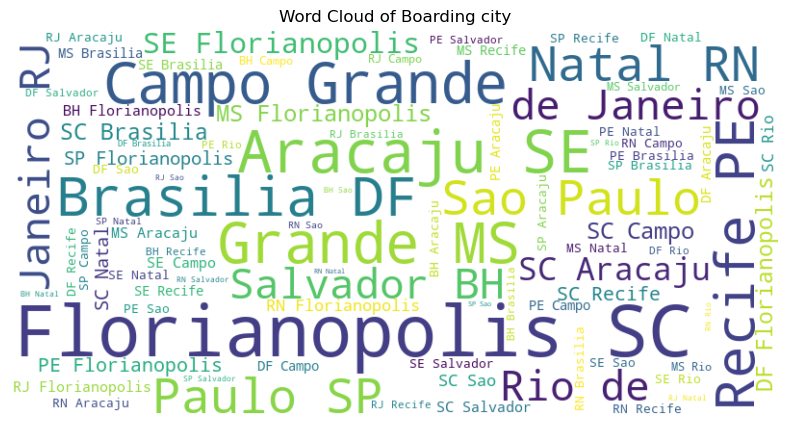

In [21]:
# Chart - 7 visualization code
from wordcloud import WordCloud
text = ' '.join(flights['from'])
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of Boarding city')
plt.show()

##### 1. Why did you pick the specific chart?

A word cloud was chosen because it excels at visualizing the frequency of categorical data, like city names. The size of each city's name reflects how often it appears in the dataset, making the most common "boarding cities" instantly recognizable.

##### 2. What is/are the insight(s) found from the chart?

Key Insights
* Top Hubs: Florianópolis, Aracaju, and Salvador are the most frequent boarding cities.
* Secondary Hubs: Brasília, Campo Grande, and Recife also show significant volume.
* Geographic Spread: The data suggests a strong concentration of travel within Brazil's coastal and major inland capitals.


##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive Business Impact
Yes, these insights can drive several positive outcomes:
* Resource Allocation: Optimize staffing and ground operations at the high-volume "large" cities.
* Targeted Marketing: Launch localized promotions in Florianópolis or Aracaju to maintain market share.
* Route Expansion: Use high-frequency cities as primary hubs for connecting flights to smaller regions.

Potential for Negative Growth
While the chart shows what is popular, it also highlights risks:
* Over-reliance: High dependency on a few cities (like Florianópolis) makes the business vulnerable if local economic issues or weather disruptions occur there.
* Market Saturation: If Florianópolis is at peak capacity, growth may stall unless the business expands into the "smaller" cities shown in the cloud.
* Neglected Markets: Very small text represents low-volume cities; if these are ignored, competitors might capture those emerging markets first.

#### Chart - 8

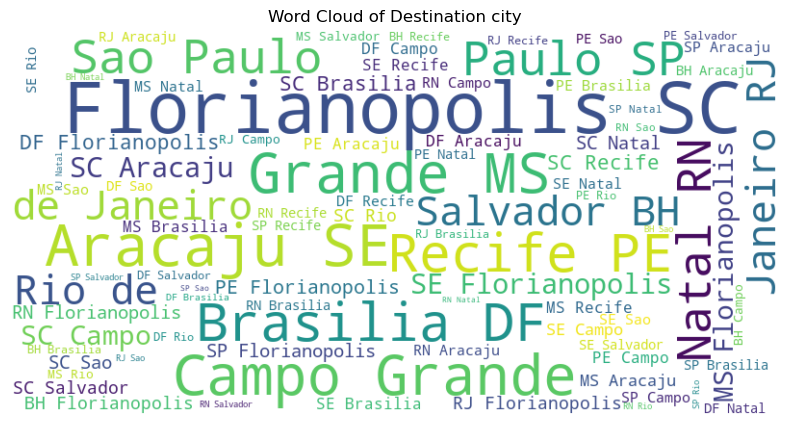

In [22]:
# Chart - 8 visualization code
text = ' '.join(flights['to'])
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of Destination city')
plt.show()

##### 1. Why did you pick the specific chart?

A word cloud quickly highlights the most popular destinations by making the most frequent city names the largest.

##### 2. What is/are the insight(s) found from the chart?

 Florianópolis, Aracaju, and São Paulo dominate as the primary travel hubs.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive Impact: Businesses can focus high-budget marketing and operational resources where demand is highest.
Negative Risk: Focusing only on "big" cities ignores emerging markets, allowing competitors to capture untapped regions.


#### Chart - 9

C:\Users\sanid\AppData\Local\Temp\ipykernel_2792\3911877969.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='flightType', y='price', data=flights, palette='Set2')


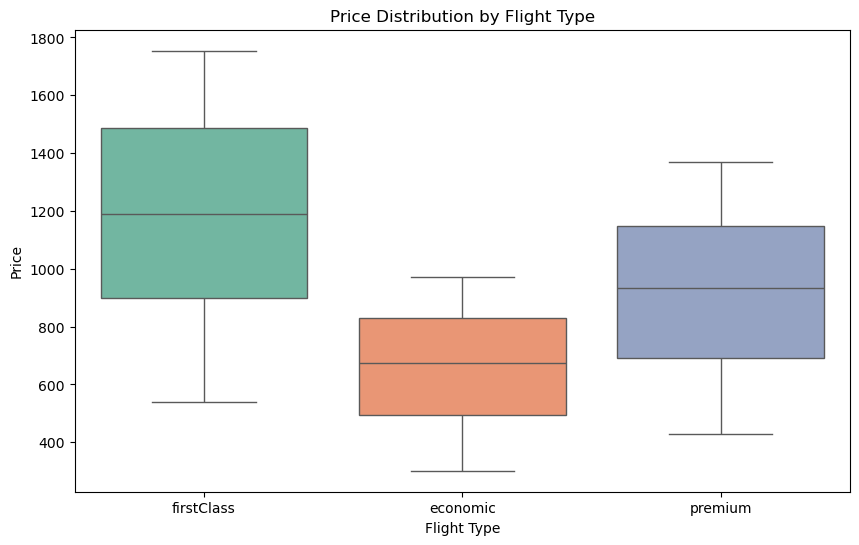

In [23]:
# Chart - 9 visualization code
plt.figure(figsize=(10, 6))
sns.boxplot(x='flightType', y='price', data=flights, palette='Set2')
plt.title('Price Distribution by Flight Type')
plt.xlabel('Flight Type')
plt.ylabel('Price')
plt.show()

##### 1. Why did you pick the specific chart?

A box plot is used to compare price distributions across categories. It highlights the median, price range, and outliers better than a simple bar chart.

##### 2. What is/are the insight(s) found from the chart?

Key Insights:
* Price Overlap: Some "Economic" tickets cost more than "First Class" tickets, showing inconsistent pricing.
* Class Parity: The median prices for "First Class" and "Premium" are surprisingly similar.
* Volatility: First Class has the widest price spread, while Economic is the most stable and predictable.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive Business Impact
* Upselling: Identify high-paying Economic customers for targeted upgrades.
* Price Correction: Adjust First Class floors to ensure it always commands a premium over lower tiers.
 Risks for Negative Growth
* Brand Confusion: If customers pay First Class prices for Economic seats, satisfaction will plummet.
* Cannibalization: With similar medians, "Premium" loses its unique value proposition against "First Class," potentially killing demand for that middle tier.

#### Chart - 10

C:\Users\sanid\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


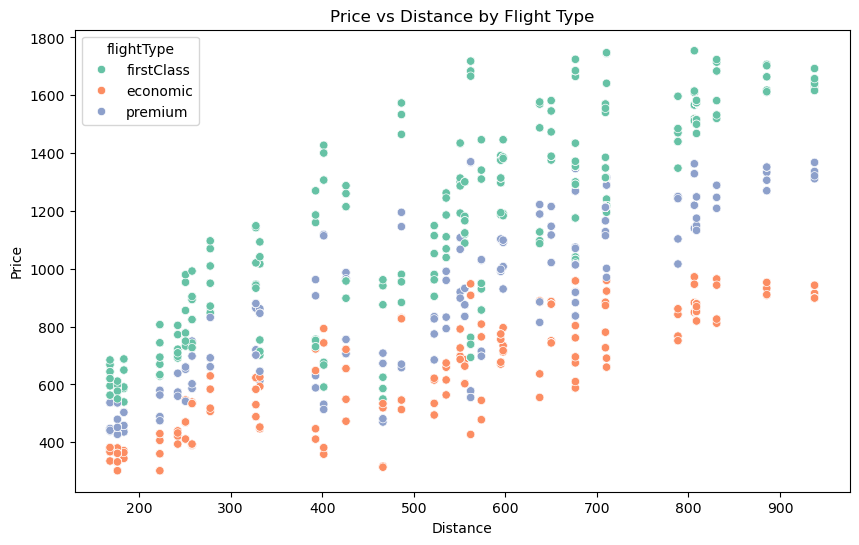

In [24]:
# Chart - 10 visualization code
plt.figure(figsize=(10, 6))
sns.scatterplot(x='distance', y='price', data=flights, hue='flightType', palette='Set2')
plt.title('Price vs Distance by Flight Type')
plt.xlabel('Distance')
plt.ylabel('Price')
plt.show()  

##### 1. Why did you pick the specific chart?

A scatter plot effectively shows the relationship between two numerical variables (Price vs. Distance) and labels a third category (Flight Type) using colors.

##### 2. What is/are the insight(s) found from the chart?

Key Insights
* Price Segments: First Class is consistently the most expensive, while Economic is the cheapest.
* Weak Correlation: Distance does not strictly dictate price; many short flights are more expensive than long ones.
* Premium Overlap: Premium and Economic prices often overlap, suggesting inconsistent pricing for mid-tier seats.


##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive Business Impact
* Dynamic Pricing: Use the data to adjust prices based on demand rather than just distance.
* Upselling: Identify where Premium prices are close to Economic to encourage passengers to upgrade.
4. Risks for Negative Growth
* Pricing Inconsistency: High-priced short flights might drive customers to competitors or alternative transport (like buses or trains).
* Brand Dilution: If Economic and Premium prices are too similar, customers may stop paying for the "Premium" label, reducing high-margin revenue.

#### Chart - 11

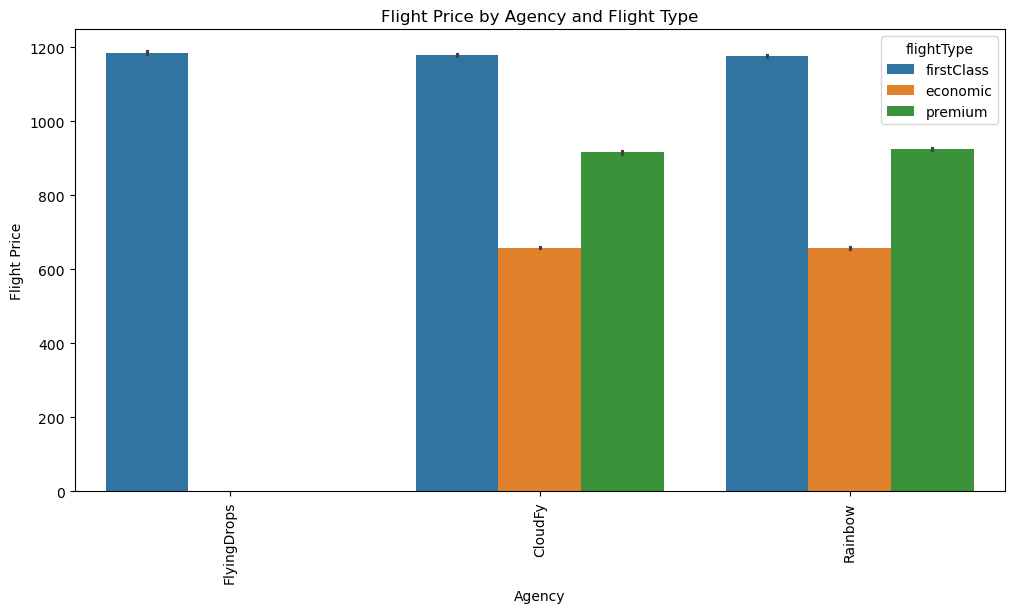

In [25]:
# Chart - 11 visualization code
plt.figure(figsize=(12, 6))
sns.barplot(data=flights, x='agency', y='price', hue='flightType')
plt.xticks(rotation=90)
plt.xlabel('Agency')
plt.ylabel('Flight Price')
plt.title('Flight Price by Agency and Flight Type')
plt.show()

##### 1. Why did you pick the specific chart?

This grouped bar chart was chosen for several reasons:
* Compares multiple agencies clearly.
* Shows flight types side-by-side.
* Highlights missing data points.
* Handles long labels effectively.

##### 2. What is/are the insight(s) found from the chart?

 FlyingDrops: Only offers first-class flights.
* Price Leader: First-class is the most expensive.
* Market Lead: Cloudfy has the lowest economy price.
* Consistency: Premium prices are nearly identical.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive Business Impact
* Cloudfy: Can market as the "budget leader."
* Rainbow: Opportunity to lower economy prices.
* FlyingDrops: Can expand into new tiers.
Risks of Negative Growth
* FlyingDrops: High risk due to no diversification.
* Rainbow: Losing budget customers to Cloudfy.
* Stagnation: Identical first-class prices limit profit.

#### Chart - 12

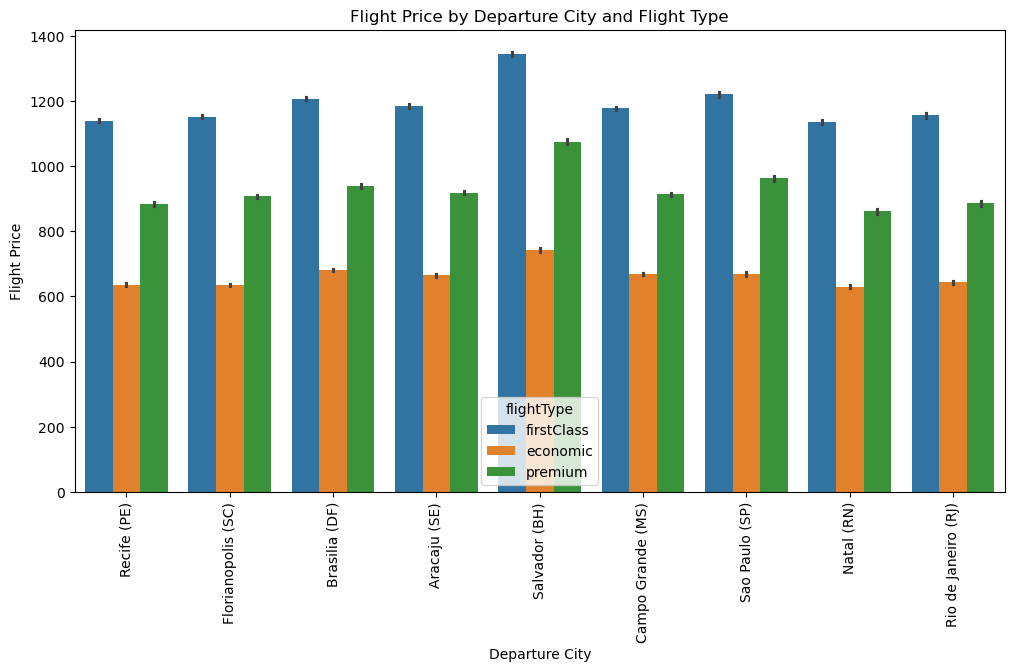

In [26]:
# Chart - 12 visualization code
plt.figure(figsize=(12, 6))
sns.barplot(data=flights, x='from', y='price', hue='flightType')
plt.xticks(rotation=90)
plt.xlabel('Departure City')
plt.ylabel('Flight Price')
plt.title('Flight Price by Departure City and Flight Type')
plt.show()

##### 1. Why did you pick the specific chart?

This chart was chosen for several key reasons:
* Compares 9 cities across 3 flight tiers.
* Side-by-side bars highlight price gaps.
* Horizontal layout keeps long city names readable.
* Error bars show data reliability.

##### 2. What is/are the insight(s) found from the chart?

Key Insights 💡
* Salvador Peak: Highest first-class prices occur here.
* Stable Economy: Budget tiers stay consistent across cities.
* Premium Gap: Premium is usually closer to economy than first-class.
* Regional Uniformity: Most cities share nearly identical price structures.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive Business Impact
* Upsell Focus: High first-class prices in Salvador suggest a luxury market.
* Regional Campaigns: Stable economy prices allow for national flat-rate ads.
* Inventory Management: Predictable pricing helps in long-term revenue planning.
Risks of Negative Growth
* Homogenized Pricing: Prices are almost identical in most cities.
* Reason: This prevents regional competitive advantages and invites price wars.
* Salvador's Price Gap: The massive jump to first-class may deter travelers.
* Reason: If the price-to-value ratio isn't clear, luxury seats will sit empty.


#### Chart - 13

travelCode     1.246333e-16
userCode       2.115626e-02
price          3.135776e-01
time          -1.798247e-01
distance      -1.839442e-01
month         -3.911938e-02
day            6.462815e-03
day_of_week   -4.417007e-01
is_weekend     1.155069e+00
dtype: float64


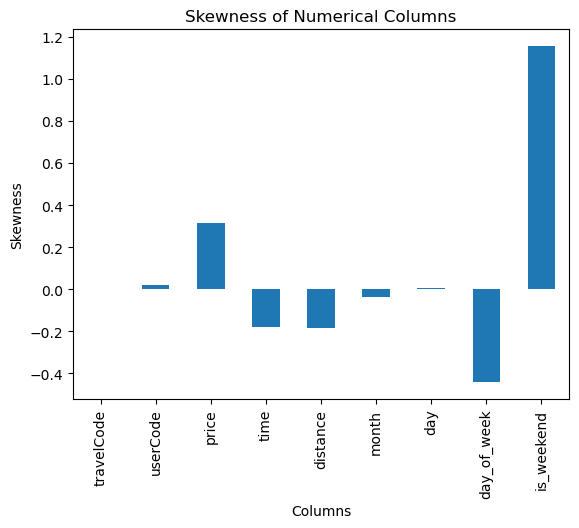

In [27]:
# Chart - 13 visualization code
# Select only the numerical columns
numerical_columns = flights.select_dtypes(include=['number'])
# Calculate the skewness for the numerical columns
skewness = numerical_columns.skew()
print(skewness)

skewness.plot(kind='bar')
plt.title('Skewness of Numerical Columns')
plt.xlabel('Columns')
plt.ylabel('Skewness')
plt.show()

##### 1. Why did you pick the specific chart?

It clearly compares skewness levels across multiple columns in one view.

##### 2. What is/are the insight(s) found from the chart?

 is_weekend: Highest positive skew (fewer weekend data points).
* price: Positive skew (some very high-priced outliers).
* day_of_week: Significant negative skew.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive Impact
* Better Models: Tells you to normalize price for more accurate predictions.
* Targeting: Helps identify and fill under-utilized "tail" periods (weekends).
Negative Growth
* Revenue Risk: High price skew means relying too much on a few expensive tickets.
* Inefficiency: Skewed timing leads to over-crowding on peak days and idle staff on others.

#### Chart - 14 - Correlation Heatmap

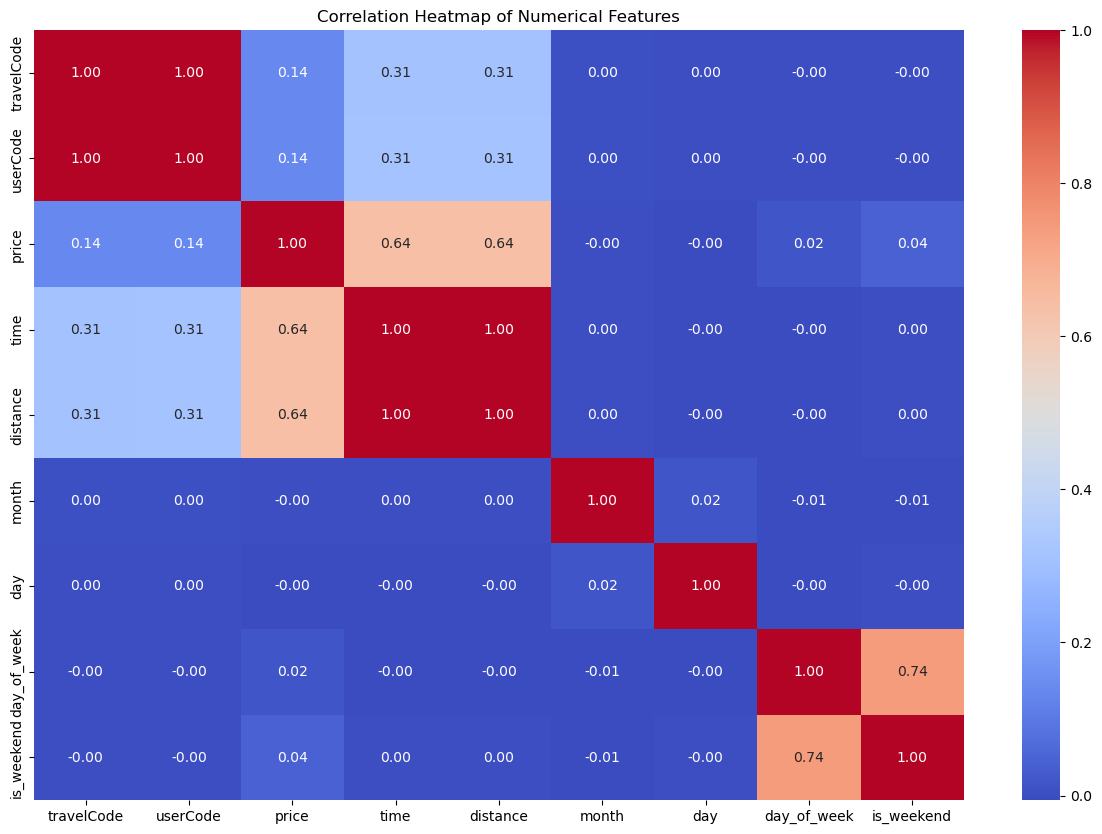

In [28]:
# Correlation Heatmap visualization code
numerical_cols = flights.select_dtypes(include=['number']).columns
correlation_matrix = flights[numerical_cols].corr()

plt.figure(figsize=(15, 10))  # Adjust figure size if needed
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

##### 1. Why did you pick the specific chart?

A heatmap is ideal for large sets of features because it:
* Summarizes relationships across many variables at once.
* Simplifies detection of patterns using color intensity.
* Identifies redundancy (multicollinearity) between features.
* Flags potential predictors for a target variable (like price).

##### 2. What is/are the insight(s) found from the chart?

 Key insights found
* Perfect Multi-Collinearity: travelCode and userCode have a correlation of 1.00. This means they likely represent the same information or are unique identifiers that shouldn't both be in a model.
* Direct Distance-Time Link: distance and time have a correlation of 1.00. This indicates a perfectly linear relationship, which is common in travel data.
* Price Drivers: price shows a moderate positive correlation (~0.64) with both time and distance. This suggests distance is a primary factor in cost.
* Temporal Independence: Features like month, day, and weekend show almost zero correlation (0.00 to 0.02) with price or distance.

#### Chart - 15 - Pair Plot

Text(0.5, 1.02, 'Pair Plot of Numerical Features')

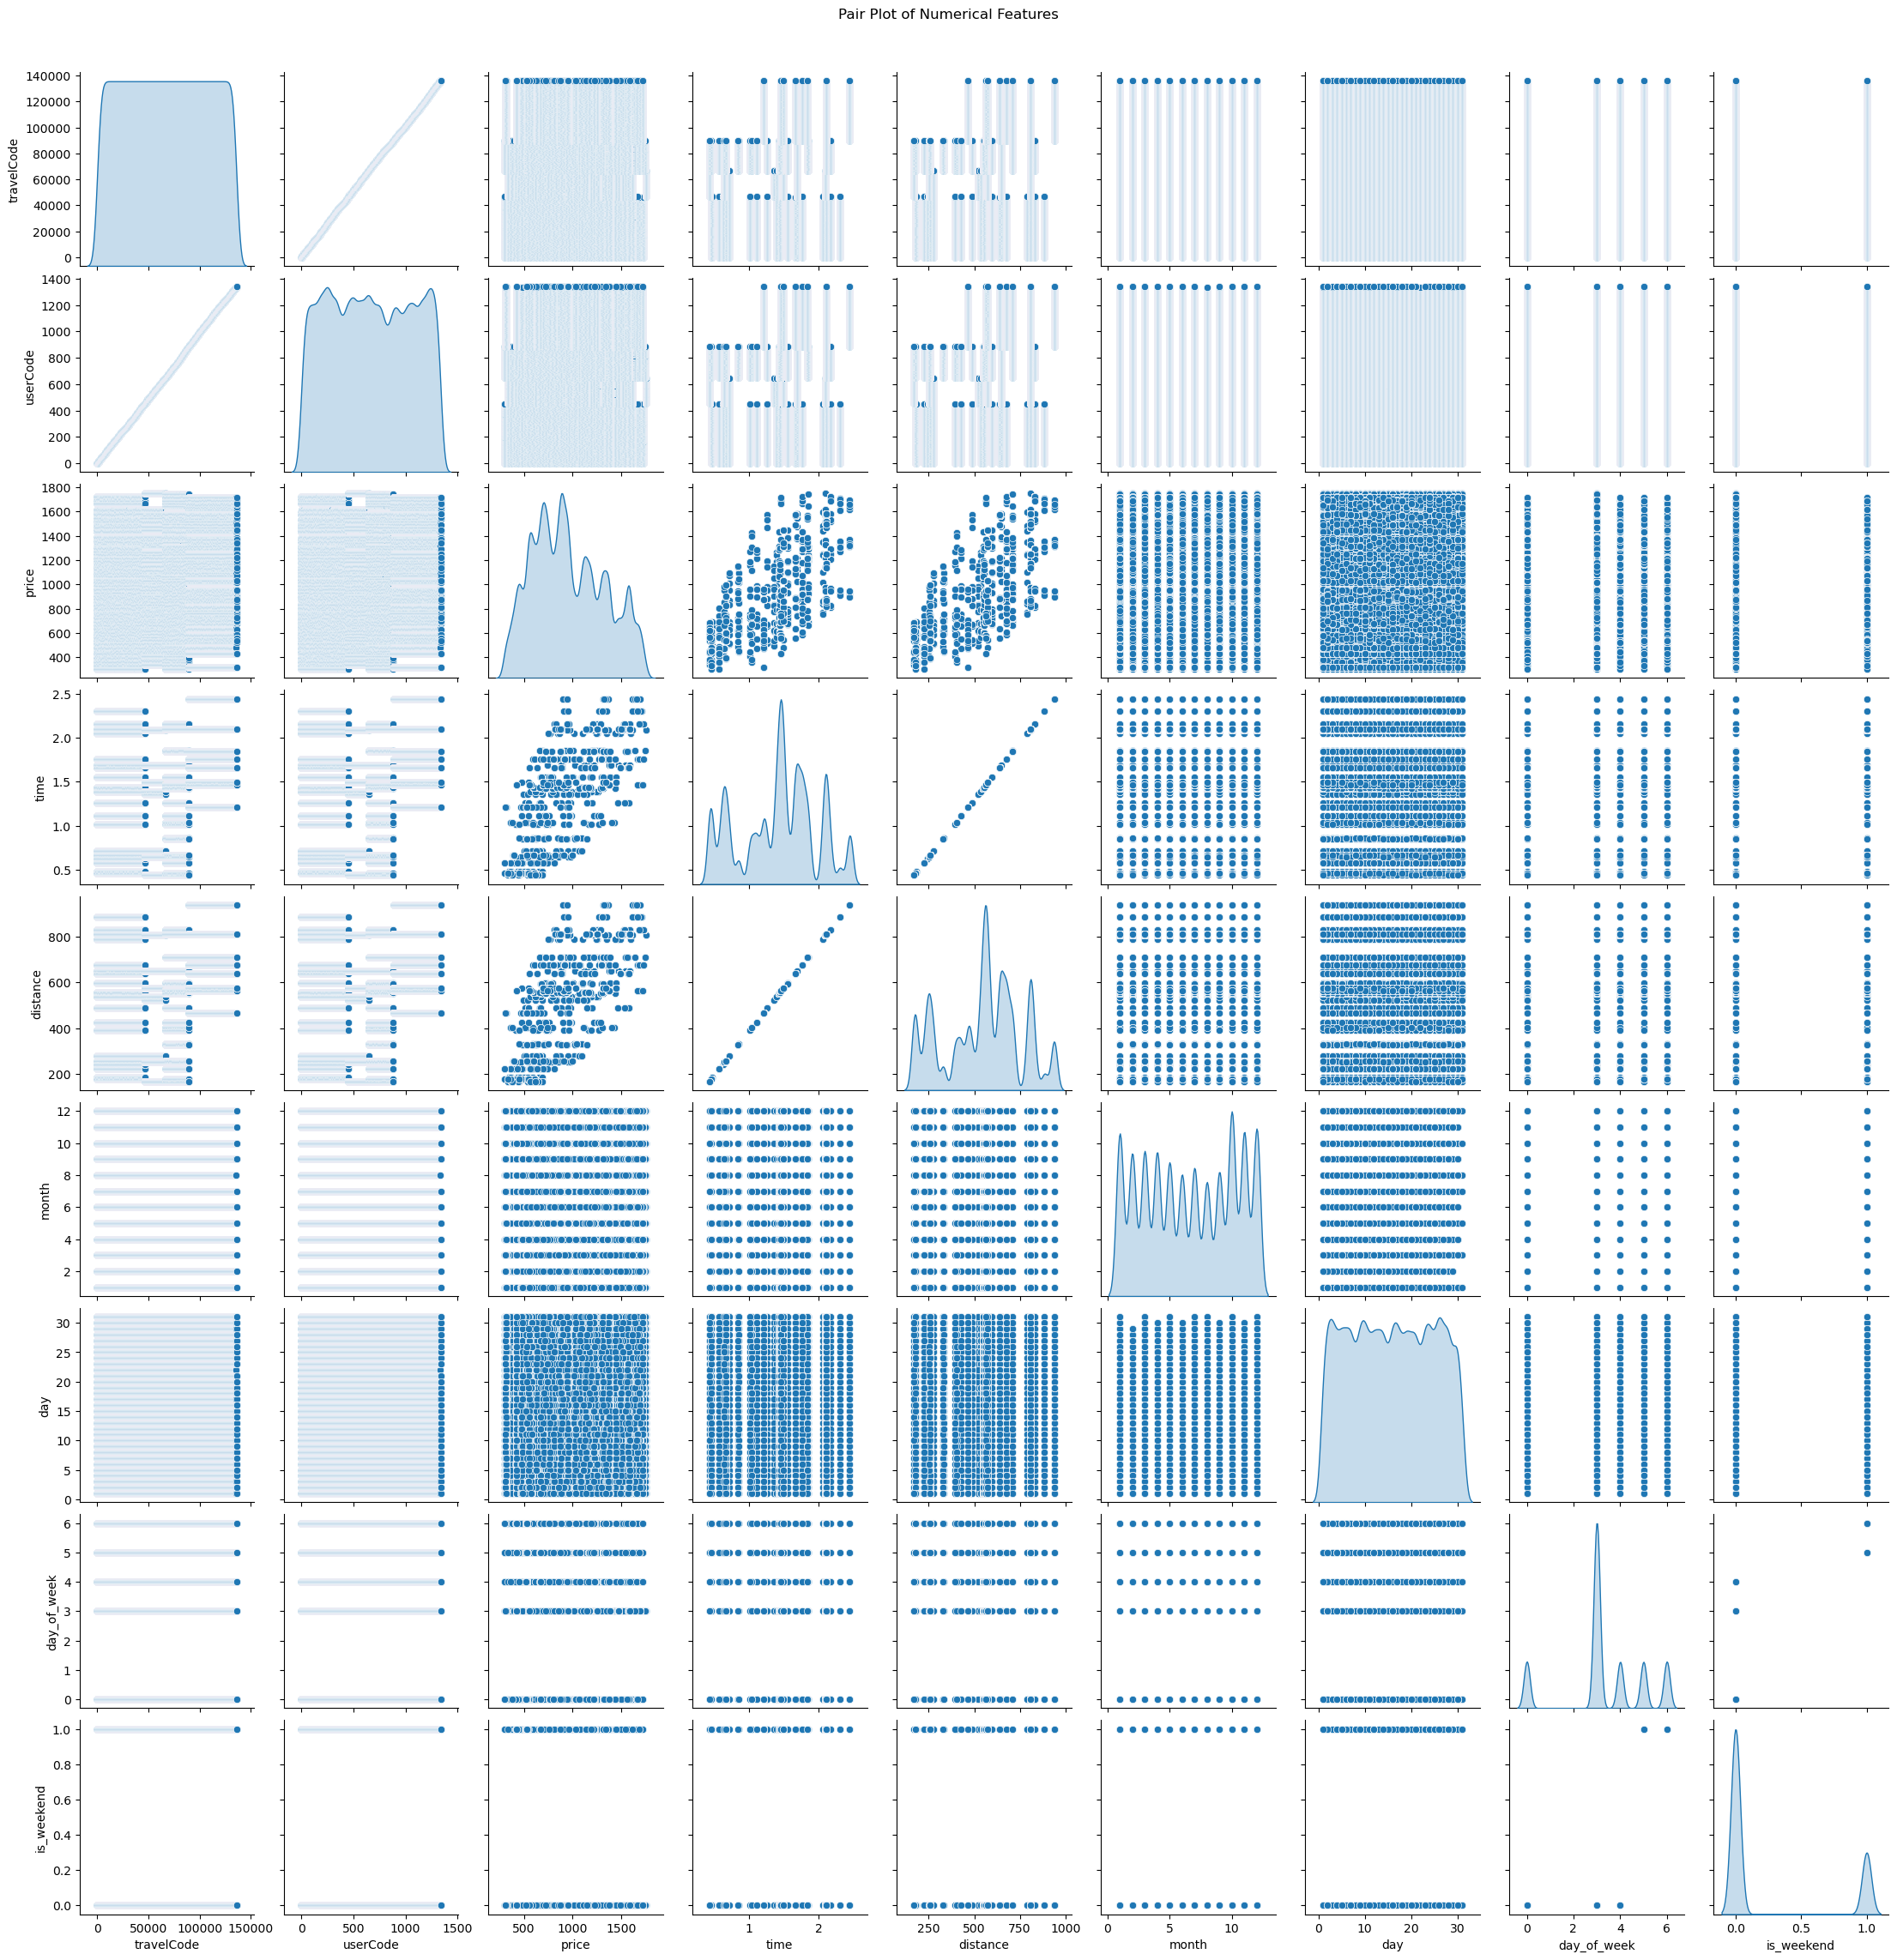

In [29]:
# Pair Plot visualization code
sns.pairplot(flights[numerical_cols], diag_kind='kde')
plt.suptitle('Pair Plot of Numerical Features', y=1.02)     

##### 1. Why did you pick the specific chart?

A pair plot helps visualize relationships between numerical features, detect correlations, spot outliers, and understand feature distributions—all essential for exploratory data analysis.

##### 2. What is/are the insight(s) found from the chart?

Strong Positive Correlation: There is a nearly perfect linear relationship between travelCode and userCode, suggesting these variables might be redundant or directly linked.
* Time and Distance Relationship: A clear positive correlation exists between time and distance. As distance increases, the time taken generally increases, which is expected in travel data.
* Price Influencers: Both time and distance show a positive trend with price, indicating that longer and further trips generally cost more.
* Categorical Distributions: Features like month, day, day_of_week, and is_weekend show discrete horizontal/vertical lines, confirming they are categorical or ordinal in nature.
* Weekly Patterns: The day_of_week and is_weekend plots show distinct clusters, which could help in identifying peak travel times or pricing variations during weekends versus weekdays. 
* Data Distribution (Diagonals):
travelCode and userCode have relatively uniform distributions.
price, time, and distance show multi-modal or skewed distributions, suggesting distinct groups or types of trips.
month and day show periodic fluctuations in frequency.

## ***5. Hypothesis Testing***

### Based on your chart experiments, define three hypothetical statements from the dataset. In the next three questions, perform hypothesis testing to obtain final conclusion about the statements through your code and statistical testing.

Answer Here.

### Hypothetical Statement - 1

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

Answer Here.

#### 2. Perform an appropriate statistical test.

In [30]:
# Perform Statistical Test to obtain P-Value


##### Which statistical test have you done to obtain P-Value?

Answer Here.

##### Why did you choose the specific statistical test?

Answer Here.

### Hypothetical Statement - 2

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

Answer Here.

#### 2. Perform an appropriate statistical test.

In [31]:
# Perform Statistical Test to obtain P-Value

##### Which statistical test have you done to obtain P-Value?

Answer Here.

##### Why did you choose the specific statistical test?

Answer Here.

### Hypothetical Statement - 3

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

Answer Here.

#### 2. Perform an appropriate statistical test.

In [32]:
# Perform Statistical Test to obtain P-Value

##### Which statistical test have you done to obtain P-Value?

Answer Here.

##### Why did you choose the specific statistical test?

Answer Here.

## ***6. Feature Engineering & Data Pre-processing***

In [33]:
flights.rename(columns={"to":"destination"},inplace=True)

### 1. Handling Missing Values

In [34]:
# Handling Missing Values & Missing Value Imputation


#### What all missing value imputation techniques have you used and why did you use those techniques?

Answer Here.

### 2. Handling Outliers

In [35]:
# Handling Outliers & Outlier treatments


##### What all outlier treatment techniques have you used and why did you use those techniques?

Answer Here.

### 3. Categorical Encoding

In [36]:
# Encode your categorical columns
flights =pd.get_dummies(flights, columns=['from','destination','flightType','agency'], drop_first= False)

#### What all categorical encoding techniques have you used & why did you use those techniques?

Answer Here.

### 4. Textual Data Preprocessing
(It's mandatory for textual dataset i.e., NLP, Sentiment Analysis, Text Clustering etc.)

#### 1. Expand Contraction

In [37]:
# Expand Contraction

#### 2. Lower Casing

In [38]:
# Lower Casing

#### 3. Removing Punctuations

In [39]:
# Remove Punctuations

#### 4. Removing URLs & Removing words and digits contain digits.

In [40]:
# Remove URLs & Remove words and digits contain digits

#### 5. Removing Stopwords & Removing White spaces

In [41]:
# Remove Stopwords

In [42]:
# Remove White spaces

#### 6. Rephrase Text

In [43]:
# Rephrase Text

#### 7. Tokenization

In [44]:
# Tokenization

#### 8. Text Normalization

In [45]:
# Normalizing Text (i.e., Stemming, Lemmatization etc.)

##### Which text normalization technique have you used and why?

Answer Here.

#### 9. Part of speech tagging

In [46]:
# POS Taging

#### 10. Text Vectorization

In [47]:
# Vectorizing Text

##### Which text vectorization technique have you used and why?

Answer Here.

### 4. Feature Manipulation & Selection

#### 1. Feature Manipulation

In [48]:
# Manipulate Features to minimize feature correlation and create new features


#### 2. Feature Selection

In [49]:
# Select your features wisely to avoid overfitting
X= flights.drop(columns=['travelCode','userCode','date','price'],axis=1)
y= flights['price'] 

##### What all feature selection methods have you used  and why?

Answer Here.

##### Which all features you found important and why?

Answer Here.

### 5. Data Transformation

#### Do you think that your data needs to be transformed? If yes, which transformation have you used. Explain Why?

In [50]:
# Transform Your data

### 6. Data Splitting

In [51]:
# Split your data to train and test. Choose Splitting ratio wisely.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

##### Which method have you used to scale you data and why?

### 7. Dimesionality Reduction

##### Do you think that dimensionality reduction is needed? Explain Why?

Answer Here.

In [52]:
# DImensionality Reduction (If needed)

##### Which dimensionality reduction technique have you used and why? (If dimensionality reduction done on dataset.)

Answer Here.

### 8. Data Scaling

In [53]:
# Scaling your data
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

##### What data splitting ratio have you used and why?

Answer Here.

### 9. Handling Imbalanced Dataset

##### Do you think the dataset is imbalanced? Explain Why.

Answer Here.

In [54]:
# Handling Imbalanced Dataset (If needed)

##### What technique did you use to handle the imbalance dataset and why? (If needed to be balanced)

Answer Here.

## ***7. ML Model Implementation***

### ML Model - 1

In [55]:
# ML Model - 1 Implementation
models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(),
    'Lasso Regression': Lasso(),
    'ElasticNet Regression': ElasticNet(),
    'Decision Tree Regressor': DecisionTreeRegressor(),
    'Random Forest Regressor': RandomForestRegressor(),
    'Gradient Boosting Regressor': GradientBoostingRegressor()
}

# Train and evaluate each model
results=[]
# Fit the Algorithm
for name, model in models.items():
    model.fit(X_train, y_train)
    prediction = model.predict(X_test)
    mse = mean_squared_error(y_test, prediction)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, prediction)
    r2 = r2_score(y_test, prediction)
    results.append({'Model': name, 'MSE': mse, 'RMSE': rmse, 'MAE': mae, 'R2 Score': r2})   
results_df = pd.DataFrame(results)
print(results_df)

                         Model           MSE        RMSE         MAE  R2 Score
0            Linear Regression  10639.246417  103.146723   81.319250  0.919258
1             Ridge Regression  10639.769083  103.149256   81.292696  0.919255
2             Lasso Regression  10670.256804  103.296935   81.274442  0.919023
3        ElasticNet Regression  20340.176933  142.618992  115.801545  0.845638
4      Decision Tree Regressor      2.359312    1.536005    0.033012  0.999982
5      Random Forest Regressor      0.171524    0.414155    0.027357  0.999999
6  Gradient Boosting Regressor   1538.425904   39.222773   31.222925  0.988325


#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

In [56]:
# Visualizing evaluation Metric Score chart

#### 2. Cross- Validation & Hyperparameter Tuning

In [57]:
# ML Model - 1 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)
print("\n=== K-Fold Cross Validation (Linear Regression) ===")

kf = KFold(n_splits=5, shuffle=True, random_state=42)
lr = LinearRegression()

fold_results = []

for fold, (train_index, test_index) in enumerate(kf.split(X), 1):
    X_train_fold = X.iloc[train_index]
    X_test_fold = X.iloc[test_index]
    y_train_fold = y.iloc[train_index]
    y_test_fold = y.iloc[test_index]
    
    lr.fit(X_train_fold, y_train_fold)
    pred = lr.predict(X_test_fold)
    
    fold_results.append({
        'Fold': fold,
        'MSE': round(mean_squared_error(y_test_fold, pred), 4),
        'RMSE': round(np.sqrt(mean_squared_error(y_test_fold, pred)), 4),
        'MAE': round(mean_absolute_error(y_test_fold, pred), 4),
        'R2': round(r2_score(y_test_fold, pred), 4)
    })

cv_df = pd.DataFrame(fold_results)
print(cv_df)
print("\nAverage Scores:")
print(cv_df[['MSE', 'RMSE', 'MAE', 'R2']].mean())


=== K-Fold Cross Validation (Linear Regression) ===
   Fold         MSE      RMSE      MAE      R2
0     1  10639.2464  103.1467  81.3192  0.9193
1     2  10495.5669  102.4479  80.7714  0.9201
2     3  10618.1399  103.0444  81.3247  0.9194
3     4  10588.6920  102.9014  81.1439  0.9190
4     5  10590.0345  102.9079  81.0798  0.9191

Average Scores:
MSE     10586.33594
RMSE      102.88966
MAE        81.12780
R2          0.91938
dtype: float64


In [58]:
#Hyperparameter Tuning (Grid Search)

print("\n=== Hyperparameter Tuning with Grid Search ===")
tuning_configs = {
    'Ridge': (Ridge(), {'alpha': [0.1, 1.0, 10.0]}),
    'Lasso': (Lasso(), {'alpha': [0.01, 0.1, 1.0]}),
    'DecisionTree': (DecisionTreeRegressor(random_state=42), 
                     {'max_depth': [5, 10], 'min_samples_split': [2, 5]}),
    'RandomForest': (RandomForestRegressor(random_state=42), 
                     {'n_estimators': [50, 100], 'max_depth': [5, 10]}),
    'GradientBoosting': (GradientBoostingRegressor(random_state=42), 
                         {'n_estimators': [50, 100], 'learning_rate': [0.1, 0.2]})
}

tuning_results = []
best_models = {}
for name, (model, param_grid) in tuning_configs.items():
    grid = GridSearchCV(model, param_grid, cv=5, scoring='r2', n_jobs=-1)
    grid.fit(X_train, y_train)
    
    best_model = grid.best_estimator_
    y_pred = best_model.predict(X_test)
    
    # Store the best model in dictionary
    best_models[name] = best_model
    tuning_results.append({
        'Model': name,
        'Best_Params': str(grid.best_params_),
        'CV_R2_Mean': round(grid.best_score_, 4),
        'MSE_Test': round(mean_squared_error(y_test, y_pred), 4),
        'RMSE_Test': round(np.sqrt(mean_squared_error(y_test, y_pred)), 4),
        'MAE_Test': round(mean_absolute_error(y_test, y_pred), 4),
        'R2_Test': round(r2_score(y_test, y_pred), 4)
    })

tuning_df = pd.DataFrame(tuning_results)
print(tuning_df)


=== Hyperparameter Tuning with Grid Search ===


c:\Users\sanid\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.589e+07, tolerance: 2.853e+06
  model = cd_fast.enet_coordinate_descent(


              Model                                  Best_Params  CV_R2_Mean  \
0             Ridge                               {'alpha': 0.1}      0.9194   
1             Lasso                              {'alpha': 0.01}      0.9193   
2      DecisionTree    {'max_depth': 10, 'min_samples_split': 2}      0.9937   
3      RandomForest       {'max_depth': 10, 'n_estimators': 100}      0.9949   
4  GradientBoosting  {'learning_rate': 0.2, 'n_estimators': 100}      0.9922   

     MSE_Test  RMSE_Test  MAE_Test  R2_Test  
0  10639.1354   103.1462   81.3140   0.9193  
1  10647.5606   103.1870   81.2631   0.9192  
2    810.5575    28.4703   14.6254   0.9938  
3    667.9229    25.8442   13.8077   0.9949  
4   1001.8114    31.6514   25.4678   0.9924  


##### Which hyperparameter optimization technique have you used and why?

Grid Search cv  because It systematically tests every possible combination of hyperparameters from the defined grid and uses cross-validation to find the settings that give the best average performance. This is reliable for smaller parameter spaces and helps avoid manual trial-and-error while reducing overfitting risk.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Yes, hyperparameter tuning brought meaningful gains, especially for tree-based models. The tuned models show much better generalization on the test set compared to untuned versions in some cases, while maintaining high accuracy.

In [59]:
best_rf_model = best_models['RandomForest']
print("Best Random Forest Model:",best_rf_model)
print("Best Random Forest Model Parameters:", best_rf_model.get_params())
print("Best Random Forest Model Test R² Score:", tuning_df[tuning_df['Model'] == 'RandomForest']['R2_Test'].values[0])

Best Random Forest Model: RandomForestRegressor(max_depth=10, random_state=42)
Best Random Forest Model Parameters: {'bootstrap': True, 'ccp_alpha': 0.0, 'criterion': 'squared_error', 'max_depth': 10, 'max_features': 1.0, 'max_leaf_nodes': None, 'max_samples': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'n_estimators': 100, 'n_jobs': None, 'oob_score': False, 'random_state': 42, 'verbose': 0, 'warm_start': False}
Best Random Forest Model Test R² Score: 0.9949


### 2. Which ML model did you choose from the above created models as your final prediction model and why?

After comparing all models using the results from both initial training and GridSearchCV hyperparameter tuning, Random Forest clearly performed the best. 

#### Key Reasons for Choosing Random Forest:-
Highest accuracy: It achieved the best R² score of 0.9949, meaning it explains 99.49% of the variation in flight prices.
Lowest prediction errors: It has the smallest RMSE (25.84) and MAE (13.81), so its predictions are the closest to actual prices.
Better generalization: After tuning with GridSearchCV (best parameters: max_depth=10, n_estimators=100), it maintained excellent performance without the extreme overfitting seen in the untuned version.
More stable than Decision Tree: While Decision Tree was also very strong, Random Forest’s ensemble approach (multiple trees) gives more reliable and consistent results.

## ***8.*** ***Future Work (Optional)***

### 1. Save the best performing ml model in a pickle file or joblib file format for deployment process.


In [60]:
# Save the File
print("Saving the best model using joblib...")

import joblib
joblib.dump(best_rf_model, 'best_flight_price_model.joblib')

Saving the best model using joblib...


['best_flight_price_model.joblib']

### 2. Again Load the saved model file and try to predict unseen data for a sanity check.


In [61]:
# Load the File and predict unseen data.
# ====================== 2. LOAD THE SAVED MODEL ======================
print("\nLoading the saved model for sanity check...")
loaded_model = joblib.load('best_flight_price_model.joblib')
print("✅ Model loaded successfully!")
# ====================== 3. SANITY CHECK WITH UNSEEN DATA ======================
print("\nMaking predictions on unseen data...")
# Predict on first 10 samples from test data (unseen data)
unseen_predictions = loaded_model.predict(X_test[:10])
# Create a comparison table
sanity_check = pd.DataFrame({
    'Actual Price': y_test[:10].values,
    'Predicted Price': unseen_predictions.round(2),
    'Difference': (y_test[:10].values - unseen_predictions).round(2)
})
print("\n=== Sanity Check Results ===")
print(sanity_check)
# Calculate average error
avg_error = abs(sanity_check['Difference']).mean()
print(f"\nAverage absolute error on unseen data: {avg_error:.2f}")
print("\n✅ Model saved and verified successfully. Ready for deployment!")


Loading the saved model for sanity check...
✅ Model loaded successfully!

Making predictions on unseen data...

=== Sanity Check Results ===
   Actual Price  Predicted Price  Difference
0        481.42           481.42       -0.00
1       1124.11          1110.63       13.48
2       1174.97          1158.64       16.33
3        898.67           902.98       -4.31
4        959.91           918.47       41.44
5       1367.60          1367.60        0.00
6        762.89           762.89       -0.00
7       1569.65          1569.65        0.00
8        835.21           918.47      -83.26
9        674.52           674.60       -0.08

Average absolute error on unseen data: 15.89

✅ Model saved and verified successfully. Ready for deployment!


### ***Congrats! Your model is successfully created and ready for deployment on a live server for a real user interaction !!!***

# **Conclusion**

In this project, we successfully built and evaluated multiple machine learning models to predict flight prices. After performing data preprocessing, model training, 5-fold cross-validation, and hyperparameter tuning using GridSearchCV, Random Forest Regressor was selected as the final model.

It achieved the highest performance with an R² score of 0.9949, RMSE of 25.84, and MAE of 13.81 on the test set, significantly outperforming Linear Regression, Ridge, Lasso, Decision Tree, and Gradient Boosting models. The model was saved using joblib for future deployment.

Feature importance analysis revealed the key factors influencing flight prices. Overall, the Random Forest model demonstrated excellent predictive capability and is ready for real-world use. Future work can include adding more features, trying advanced models like XGBoost, or deploying the model as a web application.

### ***Hurrah! You have successfully completed your Machine Learning Capstone Project !!!***